# Bi-probability plots

The classic way to see CP violation: plot $P(\nu_\mu \to \nu_e)$ against $P(\bar\nu_\mu \to \bar\nu_e)$ as the CP phase runs through $2\pi$. The locus is an ellipse, and it collapses to a point on the diagonal when there is nothing to see.

In [1]:
import sys
import os

# Works whether or not the package is installed: the notebooks sit one level
# below the repository root, as the worked examples in test/ do.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import hamiltonians2nu
import hamiltonians3nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

## Neutrinos and antineutrinos

The antineutrino Hamiltonian is the complex conjugate of the neutrino one with the matter potential reversed. Building both and scanning $\delta_{CP}$ gives the ellipse.

In [2]:
def biprobability(energy_gev, baseline_km, vcc, n_phase=400):
    """Returns P(numu->nue) and its antineutrino partner over delta_CP."""
    dcp = np.linspace(0.0, 2.0*np.pi, n_phase)
    p_nu, p_nubar = [], []
    for d in dcp:
        h_vac = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
            gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, d,
            gd.D21_NO_BF, gd.D31_NO_BF)
        h_nu = hamiltonians3nu.hamiltonian_3nu_matter(
            h_vac, energy_gev*GEV, vcc)
        # Antineutrinos: conjugate the Hamiltonian, flip V_CC
        h_bar = hamiltonians3nu.hamiltonian_3nu_matter(
            np.conj(h_vac), energy_gev*GEV, -vcc)
        p_nu.append(oscprob3nu.probabilities_3nu(
            h_nu, baseline_km*KM)[3])
        p_nubar.append(oscprob3nu.probabilities_3nu(
            h_bar, baseline_km*KM)[3])
    return np.array(p_nu), np.array(p_nubar), dcp

## In vacuum

With no matter the ellipse is centred on the diagonal: CP violation moves you along it, but neutrinos and antineutrinos stay symmetric.

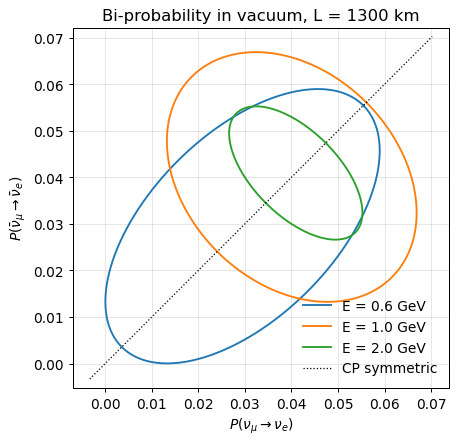

In [3]:
fig, ax = plt.subplots(figsize=(5.4, 5.2))
for e_gev in (0.6, 1.0, 2.0):
    p, pbar, dcp = biprobability(e_gev, 1300.0, 0.0)
    ax.plot(p, pbar, label="E = %.1f GeV" % e_gev)
lims = ax.get_xlim()
ax.plot(lims, lims, "k:", lw=1, label="CP symmetric")
ax.set_xlabel(r"$P(\nu_\mu \to \nu_e)$")
ax.set_ylabel(r"$P(\bar\nu_\mu \to \bar\nu_e)$")
ax.set_title("Bi-probability in vacuum, L = 1300 km")
ax.legend()
ax.set_aspect("equal", adjustable="datalim")
plt.show()

## In matter

Matter breaks the symmetry between neutrinos and antineutrinos on its own, and pushes the ellipses off the diagonal. Disentangling that from genuine CP violation is the central difficulty of a long-baseline measurement.

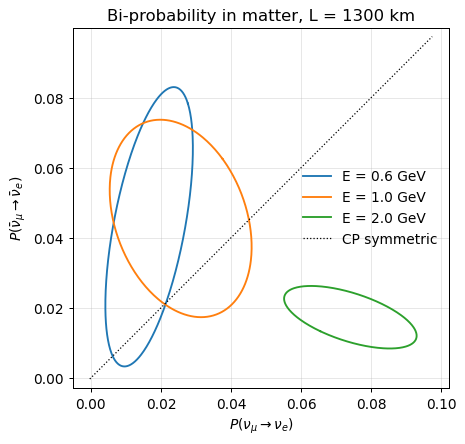

In [4]:
fig, ax = plt.subplots(figsize=(5.4, 5.2))
for e_gev in (0.6, 1.0, 2.0):
    p, pbar, dcp = biprobability(e_gev, 1300.0,
                                 gd.VCC_EARTH_CRUST)
    ax.plot(p, pbar, label="E = %.1f GeV" % e_gev)
lims = ax.get_xlim()
ax.plot(lims, lims, "k:", lw=1, label="CP symmetric")
ax.set_xlabel(r"$P(\nu_\mu \to \nu_e)$")
ax.set_ylabel(r"$P(\bar\nu_\mu \to \bar\nu_e)$")
ax.set_title("Bi-probability in matter, L = 1300 km")
ax.legend()
ax.set_aspect("equal", adjustable="datalim")
plt.show()

## Where on the ellipse

Marking a few values of $\delta_{CP}$ shows which part of the curve corresponds to which phase.

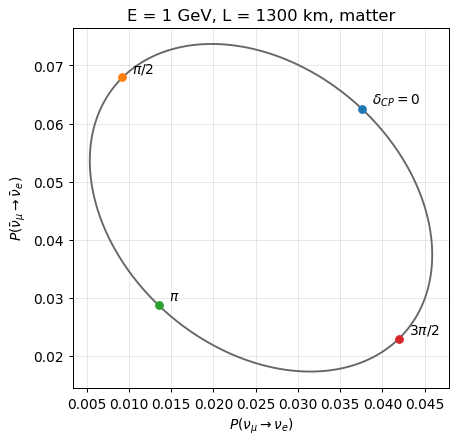

In [5]:
p, pbar, dcp = biprobability(1.0, 1300.0, gd.VCC_EARTH_CRUST)

fig, ax = plt.subplots(figsize=(5.4, 5.2))
ax.plot(p, pbar, color="0.4")
for target, label in ((0.0, r"$\delta_{CP} = 0$"),
                      (np.pi/2, r"$\pi/2$"),
                      (np.pi, r"$\pi$"),
                      (3*np.pi/2, r"$3\pi/2$")):
    k = int(np.argmin(np.abs(dcp-target)))
    ax.plot(p[k], pbar[k], "o")
    ax.annotate(label, (p[k], pbar[k]),
                textcoords="offset points", xytext=(8, 4))
ax.set_xlabel(r"$P(\nu_\mu \to \nu_e)$")
ax.set_ylabel(r"$P(\bar\nu_\mu \to \bar\nu_e)$")
ax.set_title("E = 1 GeV, L = 1300 km, matter")
plt.show()